## Introduction
Stock price prediction is a challenging task due to the inherently volatile and non-linear nature of financial markets. This project focuses on predicting Tesla Inc. (TSLA) stock prices using historical data obtained from Yahoo Finance. By leveraging time series forecasting techniques and machine learning models, we aim to capture trends and patterns that can assist in future price estimation. The dataset includes features such as historical closing prices, lagged values, and technical indicators like moving averages. We employ and compare the performance of three models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—using a time-based 80/20 train-test split. Model performance is evaluated using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the Coefficient of Determination (R²). Additionally, feature importance analysis helps us understand which inputs contribute most to the predictive power of our models.

In [2]:
#pip install yfinance scikit-learn matplotlib seaborn pandas

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

yfinance is used to fetch stock data from Yahoo Finance.

In [5]:
# Download TSLA data from Yahoo Finance
tsla_data = yf.download('TSLA', start='2015-01-01', end='2024-12-31')

[*********************100%***********************]  1 of 1 completed


Downloads historical TSLA stock data (2015–2024).

In [7]:
tsla_data.reset_index(inplace=True)

Moves the "Date" from index to a normal column.

In [9]:
tsla_data

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500
...,...,...,...,...,...,...
2510,2024-12-23,430.600006,434.510010,415.410004,431.000000,72698100
2511,2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800
2512,2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400


### Description of the column

    1. Date : 
        Description: The specific date of the trading day.
        Type: DateTime
    2. Open :
        Description: The price at which TSLA stock opened trading on that day.
        Type: Float (numeric)
    3. High :
        Description: The highest price at which TSLA stock traded during the day.
        Type: Float
    4. Low :
        Description: The lowest price TSLA stock reached during the trading day.
        Type: Float
    5. Close :
        Description: The price at which TSLA stock closed at the end of the trading day.
        Type: Float
    6. Adj Close (Adjusted Close): 
        Description: The closing price adjusted for splits and dividend payouts.
        Type: Float
    7. Volume :
        Description: Total number of TSLA shares traded on that day.
        Type: Integer

In [11]:
tsla_data.shape

(2515, 6)

In [12]:
tsla_data.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


Shows the first few rows of the dataset.

In [14]:
# calculate the number of missing values from the dataset
tsla_data.isnull().sum()

Price   Ticker
Date              0
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

In [15]:
tsla_data.tail()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
2510,2024-12-23,430.600006,434.510010,415.410004,431.000000,72698100
2511,2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800
2512,2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400
2513,2024-12-27,431.660004,450.000000,426.500000,449.519989,82666800
2514,2024-12-30,417.410004,427.000000,415.750000,419.399994,64941000


Shows the last few rows of the dataset.

In [17]:
#Provides a concise summary including row count, column names, data types, and number of non-null values. Helps identify missing data.
tsla_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        2515 non-null   datetime64[ns]
 1   (Close, TSLA)   2515 non-null   float64       
 2   (High, TSLA)    2515 non-null   float64       
 3   (Low, TSLA)     2515 non-null   float64       
 4   (Open, TSLA)    2515 non-null   float64       
 5   (Volume, TSLA)  2515 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 118.0 KB


Provides a concise summary including row count, column names, data types, and number of non-null values. Helps identify missing data.

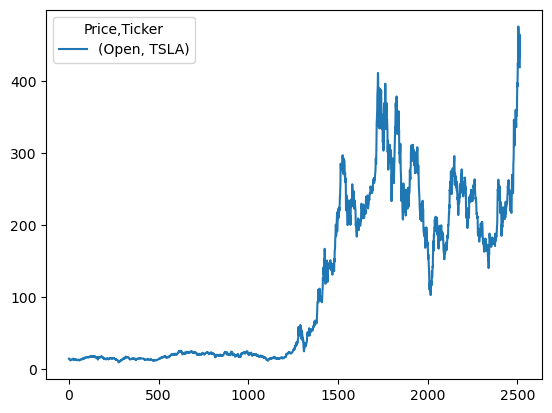

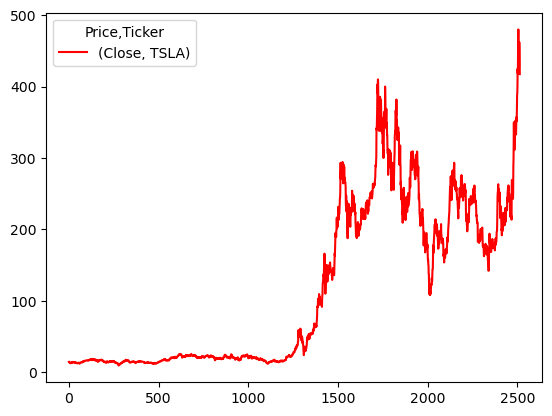

In [19]:
tsla_data[['Open']].plot(kind='line')
tsla_data[['Close']].plot(kind='line',color = 'red')
plt.show()

"Close" column represents the closing price of a stock on a specific date

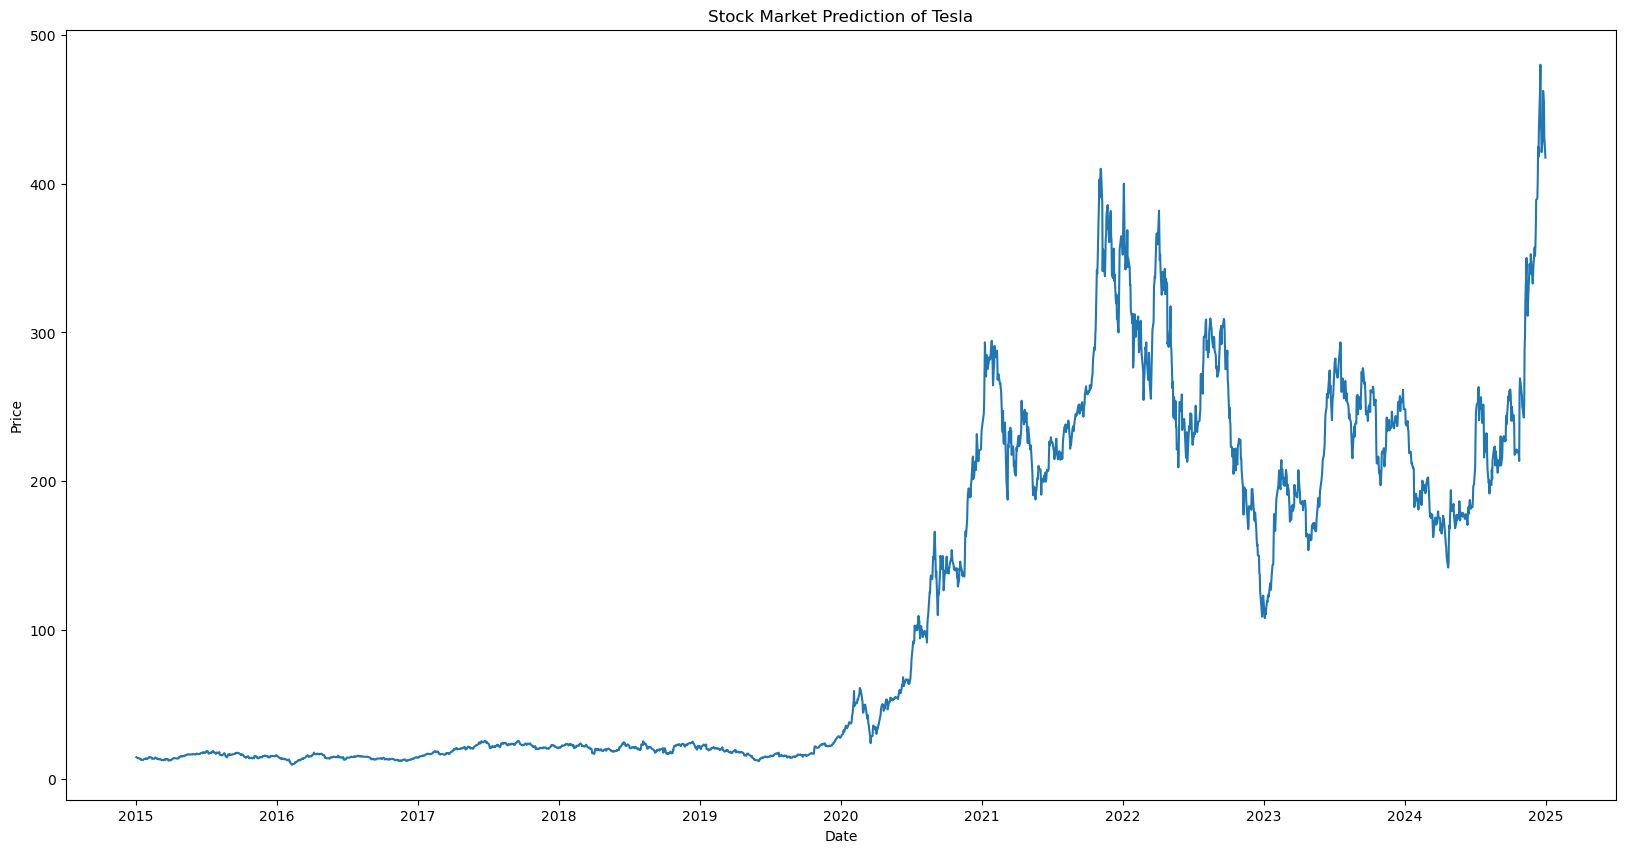

In [21]:
plt.figure(figsize=(20, 10))
plt.plot(tsla_data['Date'], tsla_data['Close'])
plt.title('Stock Market Prediction of Tesla')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

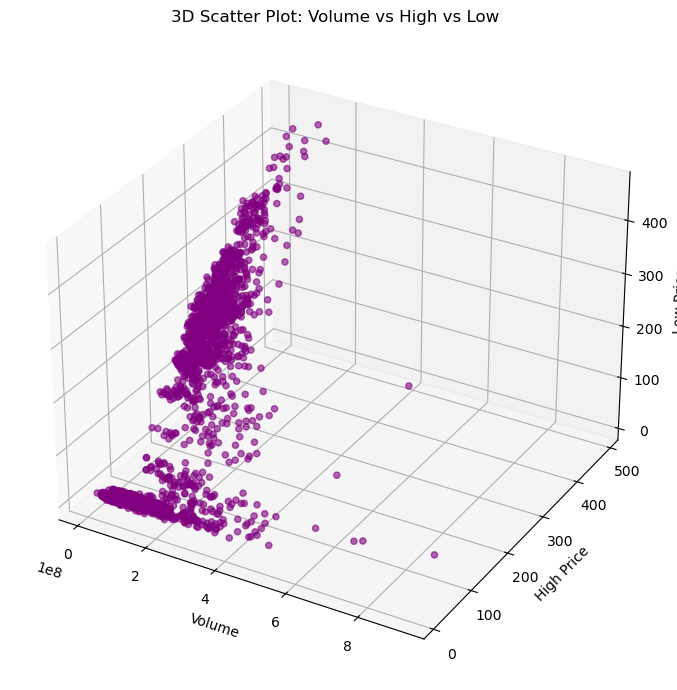

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1 ,1, 1, projection='3d')

ax.scatter(tsla_data['Volume'], tsla_data['High'], tsla_data['Low'], c='purple', alpha=0.6)
ax.set_xlabel('Volume')
ax.set_ylabel('High Price')
ax.set_zlabel('Low Price')
ax.set_title('3D Scatter Plot: Volume vs High vs Low')

plt.tight_layout()
plt.show()

#### Feature Engineering (Lag Features & Technical Indicators)

In [24]:
# Lag Features
tsla_data['Close_Lag1'] = tsla_data['Close'].shift(1)
tsla_data['Close_Lag2'] = tsla_data['Close'].shift(2)

Creates lag features (yesterday and day before yesterday's closing prices).

In [26]:
# Technical Indicators: Moving Averages
tsla_data['MA7'] = tsla_data['Close'].rolling(window=7).mean()
tsla_data['MA21'] = tsla_data['Close'].rolling(window=21).mean()

Calculates 7-day and 21-day moving averages for the closing price.

In [28]:
# Drop rows with NaNs (due to lagging and rolling)
tsla_data.dropna(inplace=True)

Removes rows with missing values (caused by rolling & shifting).

In [30]:
# Set target
tsla_data['Target'] = tsla_data['Close']

Sets the Close price as the prediction target.

#### Train-Test Split (Time-Based 80/20)

In [33]:
# Time-based split
train_size = int(len(tsla_data) * 0.8)
train = tsla_data[:train_size]
test = tsla_data[train_size:]

Splits data into 80% training and 20% testing based on time.

In [35]:
# Features and Target
features = ['Close_Lag1', 'Close_Lag2', 'MA7', 'MA21']
X_train = train[features]
y_train = train['Target']
X_test = test[features]
y_test = test['Target']

Separates features and target for both training and testing.

#### Linear Regression Model

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
# Train Linear Regression
lr_model = LinearRegression()

In [41]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [42]:
#make prediction on the test set
y_pred_lr = lr_model.predict(X_test)

Trains Linear Regression and predicts test data

In [44]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

Calculates evaluation metrics

In [46]:
print("Linear Regression Performance:")
print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

Linear Regression Performance:
MAE: 5.89, MSE: 69.49, RMSE: 8.34, R²: 0.9792


### Visual Representation of the actual and predicted values for the stock market price of tesla

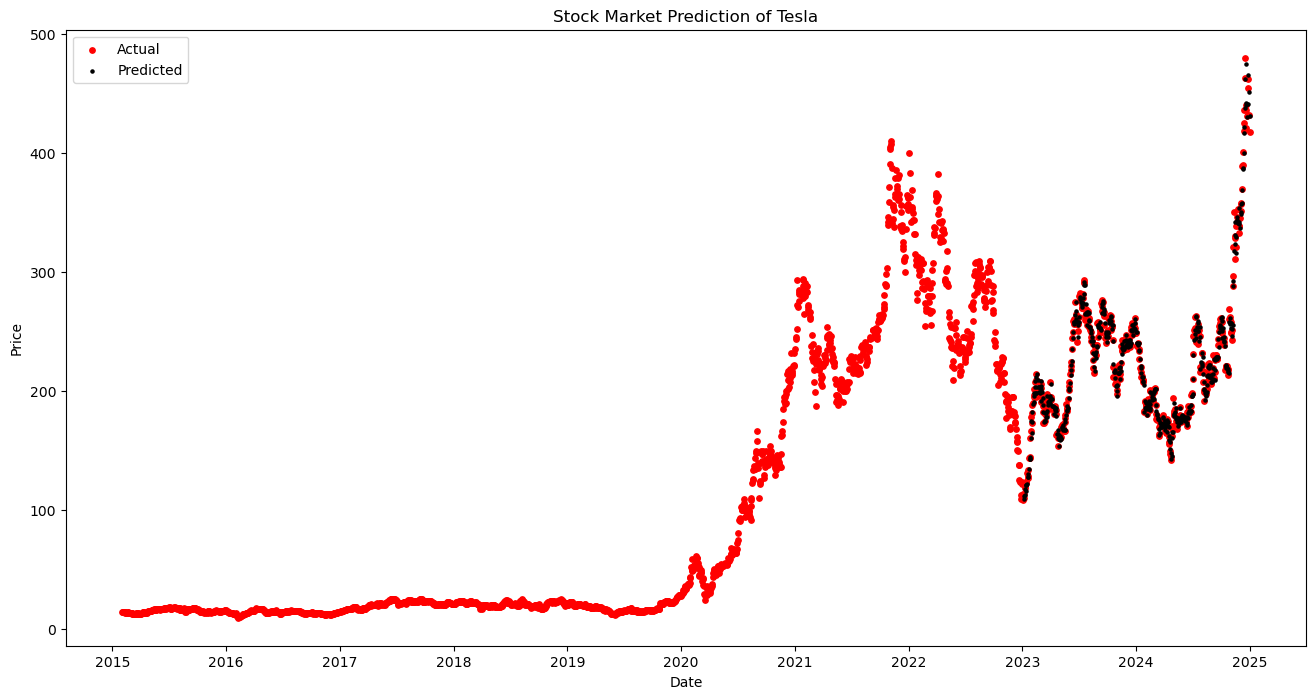

In [48]:
plt.figure(figsize=(16,8))
#Scatter plot for actual values
plt.scatter(tsla_data['Date'], tsla_data['Close'], label='Actual', color="red", s=15)
#line chart for predicted values
plt.scatter(tsla_data.loc[X_test.index, 'Date'], y_pred_lr, label='Predicted', color="black",s=5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Market Prediction of Tesla')
plt.legend()
plt.show()

#### Decision Tree Regressor

In [50]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

In [51]:
# Hyperparameter Tuning
param_grid = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeRegressor(random_state=42)
grid_tree = GridSearchCV(tree, param_grid, cv=3)
grid_tree.fit(X_train, y_train)
y_pred_tree = grid_tree.predict(X_test)

#max_depth: How deep the tree can go
#min_samples_split: Minimum samples needed to split a node

In [53]:
# Evaluation
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

In [54]:
print("Decision Tree Performance:")
print(f"MAE: {mae_tree:.2f}, MSE: {mse_tree:.2f}, RMSE: {rmse_tree:.2f}, R²: {r2_tree:.4f}")

Decision Tree Performance:
MAE: 8.81, MSE: 161.56, RMSE: 12.71, R²: 0.9516


#### Random Forest Regressor + Feature Importance

In [56]:
from sklearn.ensemble import RandomForestRegressor

In [57]:
# Hyperparameter tuning
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

In [58]:
rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf, param_rf, cv=3)
grid_rf.fit(X_train, y_train)
y_pred_rf = grid_rf.predict(X_test)

In [59]:
# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [60]:
print("Random Forest Performance:")
print(f"MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")

Random Forest Performance:
MAE: 7.57, MSE: 148.55, RMSE: 12.19, R²: 0.9555


In [61]:
# Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [62]:
feature_importance = grid_rf.best_estimator_.feature_importances_
features_sorted = pd.Series(feature_importance, index=features).sort_values(ascending=False)

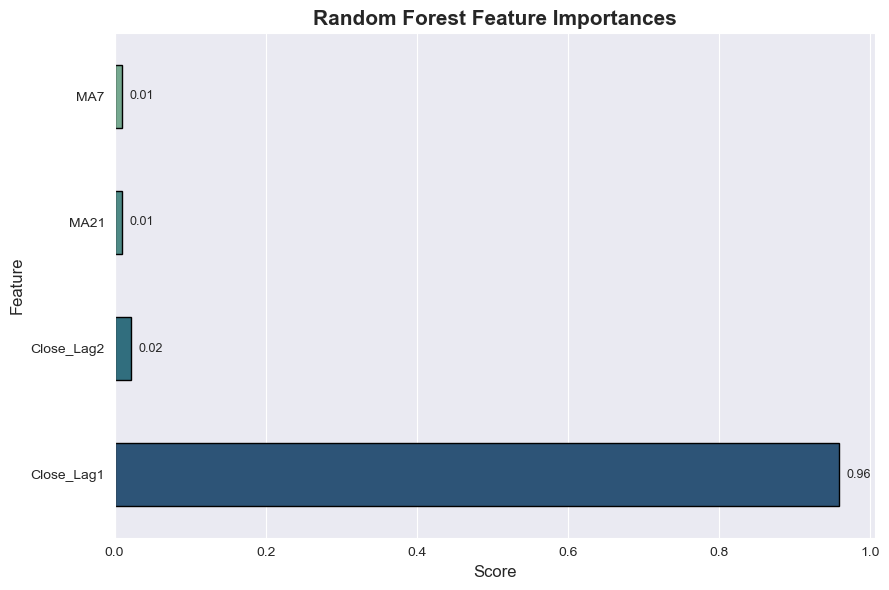

In [63]:
# Sort feature importances
features_sorted = features_sorted.sort_values(ascending=True)

# Plot
plt.figure(figsize=(9, 6))
sns.set_style("darkgrid")
ax = sns.barplot(x=features_sorted.values, y=features_sorted.index, palette="crest", edgecolor="black",width = 0.5)

# Add value labels
for i, v in enumerate(features_sorted.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=9)

plt.title("Random Forest Feature Importances", fontsize=15, weight='bold')
plt.xlabel("Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()


## Conclusion
In this study, we successfully developed predictive models for TSLA stock prices using time-series historical data enriched with lag features and technical indicators. Among the models tested, the Random Forest Regressor demonstrated superior performance, yielding lower error rates and higher R² compared to Linear Regression and Decision Tree models. This suggests that ensemble methods can effectively capture complex, non-linear patterns in stock price movements. Furthermore, the feature importance analysis provided valuable insights into which lag and technical indicators most influence price prediction. Overall, this project showcases the practical application of machine learning in financial forecasting and lays the groundwork for building more robust and scalable trading decision systems in the future.